In [1]:
# ============================================
# CELLULE 1 - INSTALLATION & IMPORTS
# ============================================

# Installer les librairies nécessaires
!pip install pandas numpy matplotlib seaborn textblob wordcloud nltk scikit-learn -q

# Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
import re
import nltk
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Télécharger les ressources NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Configuration
pd.set_option('display.max_colwidth', 100)
sns.set_style("whitegrid")

print("✅ Toutes les librairies sont importées")

✅ Toutes les librairies sont importées


In [2]:
# ============================================
# CELLULE 2 - UPLOAD DU FICHIER
# ============================================

from google.colab import files
import io

print("="*60)
print("UPLOAD DU FICHIER DES RÉCLAMATIONS")
print("="*60)
print("""
📤 Veuillez uploader le fichier :
   1. Dim_Reclamations.csv

👉 Cliquez sur 'Choisir des fichiers' et sélectionnez le CSV
""")

uploaded = files.upload()

# Charger le fichier
for nom_fichier in uploaded.keys():
    df_reclamations = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))
    print(f"✅ {nom_fichier} chargé : {df_reclamations.shape[0]} lignes")

print("\n📋 Aperçu des données :")
df_reclamations.head()

UPLOAD DU FICHIER DES RÉCLAMATIONS

📤 Veuillez uploader le fichier :
   1. Dim_Reclamations.csv

👉 Cliquez sur 'Choisir des fichiers' et sélectionnez le CSV



Saving Dim_Canal_Distribution.csv to Dim_Canal_Distribution.csv
Saving Dim_Client.csv to Dim_Client.csv
Saving Dim_Commandes.csv to Dim_Commandes.csv
Saving Dim_Date.csv to Dim_Date.csv
Saving Dim_Fournisseur.csv to Dim_Fournisseur.csv
Saving Dim_Matiere_Premiere.csv to Dim_Matiere_Premiere.csv
Saving Dim_Produits.csv to Dim_Produits.csv
Saving Dim_Reclamations.csv to Dim_Reclamations.csv
Saving Fact_Achat.csv to Fact_Achat.csv
Saving Fact_Vente.csv to Fact_Vente.csv
✅ Dim_Canal_Distribution.csv chargé : 4 lignes
✅ Dim_Client.csv chargé : 446 lignes
✅ Dim_Commandes.csv chargé : 442 lignes
✅ Dim_Date.csv chargé : 1461 lignes
✅ Dim_Fournisseur.csv chargé : 67 lignes
✅ Dim_Matiere_Premiere.csv chargé : 62 lignes
✅ Dim_Produits.csv chargé : 134 lignes
✅ Dim_Reclamations.csv chargé : 100 lignes
✅ Fact_Achat.csv chargé : 140 lignes
✅ Fact_Vente.csv chargé : 1386 lignes

📋 Aperçu des données :


,vente_key,date_key,client_key,canal_key,produit_key,commande_key,reclamation_key,quantite,prix_unitaire_ht,montant_ht,montant_tva,montant_ttc,montant_remise,revenue
0,1,20250327,1,1,0,0,NaN,850,66.5,56525.0,10739.750,67264.750,0,56525.0
1,2,20250327,1,1,0,0,NaN,1,1500.0,1500.0,285.000,1785.000,0,1500.0
2,3,20250306,3,1,0,0,NaN,33,66.5,2194.5,416.955,2611.455,0,2194.5
3,4,20251126,4,1,0,0,NaN,5,220.0,1100.0,209.000,1309.000,0,1100.0
4,5,20251126,4,1,0,0,NaN,15,170.0,2550.0,484.500,3034.500,0,2550.0


In [6]:
# ============================================
# CELLULE CORRECTIVE - UPLOAD DIM_RECLAMATIONS
# ============================================

print("="*60)
print("UPLOAD DU BON FICHIER")
print("="*60)
print("""
📤 Vous avez chargé Fact_Vente.csv par erreur.
   Il faut charger Dim_Reclamations.csv

👉 Cliquez sur 'Choisir des fichiers' et sélectionnez Dim_Reclamations.csv
""")

from google.colab import files
import io

# Upload du bon fichier
uploaded_reclamations = files.upload()

# Charger le fichier
for nom_fichier in uploaded_reclamations.keys():
    df_reclamations = pd.read_csv(io.BytesIO(uploaded_reclamations[nom_fichier]))
    print(f"✅ {nom_fichier} chargé : {df_reclamations.shape[0]} lignes, {df_reclamations.shape[1]} colonnes")

# Afficher les colonnes
print(f"\n📋 Colonnes du fichier de réclamations :")
print(df_reclamations.columns.tolist())

# Vérifier que c'est le bon fichier
if 'Type_Reclamation' in df_reclamations.columns or 'Description' in df_reclamations.columns:
    print("\n✅ C'est le bon fichier ! Les colonnes 'Type_Reclamation' et 'Description' sont présentes.")
else:
    print("\n⚠️ Ce n'est toujours pas le bon fichier. Vérifie que tu as sélectionné Dim_Reclamations.csv")

UPLOAD DU BON FICHIER

📤 Vous avez chargé Fact_Vente.csv par erreur.
   Il faut charger Dim_Reclamations.csv

👉 Cliquez sur 'Choisir des fichiers' et sélectionnez Dim_Reclamations.csv



Saving Dim_Reclamations.csv to Dim_Reclamations (1).csv
✅ Dim_Reclamations (1).csv chargé : 100 lignes, 8 colonnes

📋 Colonnes du fichier de réclamations :
['Id_Reclamation', 'Date_Reclamation', 'Nom', 'Prenom', 'Produit', 'Type_Reclamation', 'Description', 'Statut']

✅ C'est le bon fichier ! Les colonnes 'Type_Reclamation' et 'Description' sont présentes.


EXPLORATION DES RÉCLAMATIONS
Colonnes disponibles : ['Id_Reclamation', 'Date_Reclamation', 'Nom', 'Prenom', 'Produit', 'Type_Reclamation', 'Description', 'Statut']

📊 Nombre total de réclamations : 100

📊 Distribution par type de réclamation :
   Emballage abîmé : 16 (16.0%)
   Produit non conforme : 11 (11.0%)
   Produit manquant : 11 (11.0%)
   Retard de livraison : 11 (11.0%)
   Défaut de fabrication : 11 (11.0%)
   Couleur différente : 11 (11.0%)
   Livraison tardive : 9 (9.0%)
   Taille incorrecte : 8 (8.0%)
   Erreur de commande : 7 (7.0%)
   Produit endommagé : 5 (5.0%)

📊 Distribution par statut :
   En cours : 40 (40.0%)
   Résolu : 24 (24.0%)
   Rejeté : 19 (19.0%)
   En attente : 17 (17.0%)

📊 Top 5 produits les plus réclamés :
   Ensemble Décoratif Minimaliste en Résine Blanche -... : 5
   Cruche en céramique circulaire avec motifs andalou... : 5
   Ensemble Décoratif en Résine Marbrée avec Fleurs S... : 4
   Boîte carrée en céramique “Azur” – Motifs géométri... : 3
   Boug

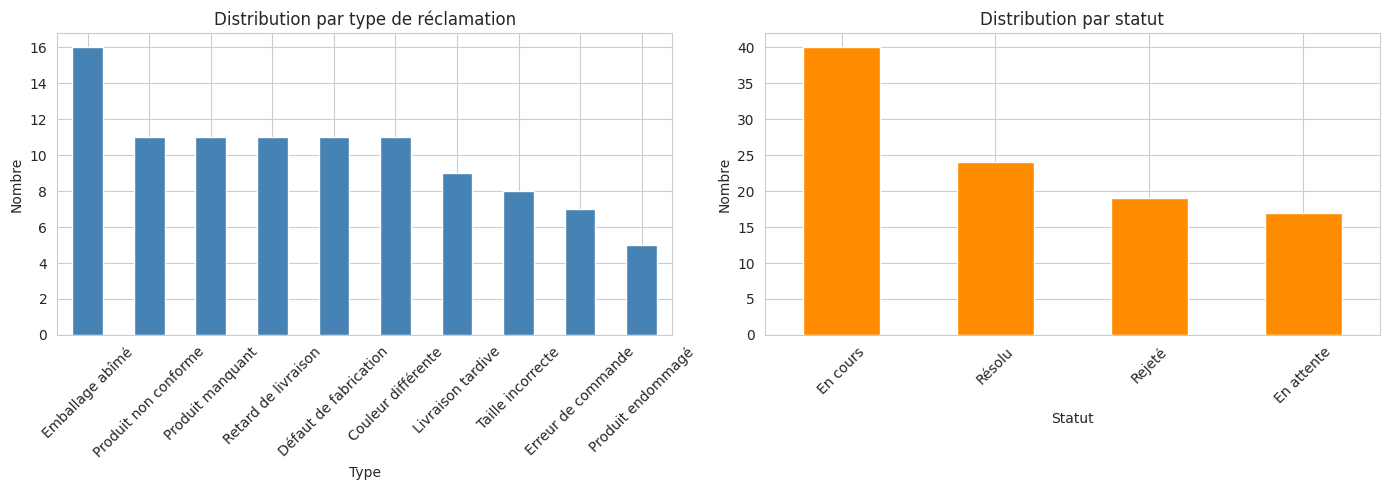

In [7]:
# ============================================
# CELLULE 3 - EXPLORATION DES RÉCLAMATIONS (CORRIGÉE)
# ============================================

print("="*60)
print("EXPLORATION DES RÉCLAMATIONS")
print("="*60)

# Afficher les colonnes
print("Colonnes disponibles :", df_reclamations.columns.tolist())

print(f"\n📊 Nombre total de réclamations : {len(df_reclamations)}")

# Distribution par type de réclamation
if 'Type_Reclamation' in df_reclamations.columns:
    print("\n📊 Distribution par type de réclamation :")
    type_counts = df_reclamations['Type_Reclamation'].value_counts()
    for type_name, count in type_counts.items():
        print(f"   {type_name} : {count} ({count/len(df_reclamations)*100:.1f}%)")
else:
    print("\n⚠️ Colonne 'Type_Reclamation' non trouvée")
    # Chercher une colonne similaire
    for col in df_reclamations.columns:
        if 'type' in col.lower():
            print(f"   → Colonne alternative trouvée : {col}")

# Distribution par statut
if 'Statut' in df_reclamations.columns:
    print("\n📊 Distribution par statut :")
    status_counts = df_reclamations['Statut'].value_counts()
    for status, count in status_counts.items():
        print(f"   {status} : {count} ({count/len(df_reclamations)*100:.1f}%)")
else:
    print("\n⚠️ Colonne 'Statut' non trouvée")

# Top produits réclamés
if 'Produit' in df_reclamations.columns:
    print("\n📊 Top 5 produits les plus réclamés :")
    top_produits = df_reclamations['Produit'].value_counts().head(5)
    for produit, count in top_produits.items():
        print(f"   {produit[:50]}... : {count}")
else:
    print("\n⚠️ Colonne 'Produit' non trouvée")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'Type_Reclamation' in df_reclamations.columns:
    type_counts.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Distribution par type de réclamation')
    axes[0].set_xlabel('Type')
    axes[0].set_ylabel('Nombre')
    axes[0].tick_params(axis='x', rotation=45)

if 'Statut' in df_reclamations.columns:
    status_counts.plot(kind='bar', ax=axes[1], color='darkorange')
    axes[1].set_title('Distribution par statut')
    axes[1].set_xlabel('Statut')
    axes[1].set_ylabel('Nombre')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# ============================================
# CELLULE 4 - NETTOYAGE DU TEXTE
# ============================================

print("="*60)
print("NETTOYAGE DES DESCRIPTIONS")
print("="*60)

# Liste des stopwords français
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words_fr = set(stopwords.words('french'))
# Ajouter des mots personnalisés
stop_words_fr.update(['le', 'la', 'les', 'un', 'une', 'des', 'et', 'à', 'dans', 'pour', 'par',
                      'je', 'tu', 'il', 'elle', 'on', 'nous', 'vous', 'ils', 'elles',
                      'ce', 'cet', 'cette', 'ces', 'mon', 'ton', 'son', 'ma', 'ta', 'sa',
                      'me', 'te', 'se', 'lui', 'leur', 'eux', 'ça', 'cela', 'cet', 'cette',
                      'est', 'sont', 'avoir', 'être', 'faire', 'peut', 'bien', 'très'])

def clean_text(text):
    """Nettoie le texte : minuscules, suppression ponctuation, stopwords"""
    if pd.isna(text):
        return ""

    # Mettre en minuscules
    text = str(text).lower()

    # Supprimer la ponctuation et les chiffres
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)

    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokeniser
    tokens = text.split()

    # Supprimer les stopwords et mots trop courts
    tokens = [word for word in tokens if word not in stop_words_fr and len(word) > 2]

    return ' '.join(tokens)

# Trouver la colonne de description
desc_col = None
for col in df_reclamations.columns:
    if 'description' in col.lower():
        desc_col = col
        break

if desc_col:
    print(f"Colonne description trouvée : {desc_col}")
    df_reclamations['Description_clean'] = df_reclamations[desc_col].apply(clean_text)
    print("✅ Texte nettoyé")

    # Exemple de nettoyage
    print("\n📋 Exemple de nettoyage :")
    for i in range(min(3, len(df_reclamations))):
        print(f"\nOriginal : {str(df_reclamations[desc_col].iloc[i])[:100]}...")
        print(f"Nettoyé  : {df_reclamations['Description_clean'].iloc[i][:100]}...")

    # Vérifier les descriptions vides
    empty_descriptions = (df_reclamations['Description_clean'] == '').sum()
    print(f"\n📊 Descriptions vides après nettoyage : {empty_descriptions}")
else:
    print("⚠️ Colonne description non trouvée")

NETTOYAGE DES DESCRIPTIONS
Colonne description trouvée : Description
✅ Texte nettoyé

📋 Exemple de nettoyage :

Original : J'ai reçu un produit différent de celui que j'avais commandé....
Nettoyé  : reçu produit différent celui commandé...

Original : L'emballage est très abîmé à la réception, heureusement le produit est intact....
Nettoyé  : emballage abîmé réception heureusement produit intact...

Original : Le produit reçu ne correspond pas à la description sur le site....
Nettoyé  : produit reçu correspond description site...

📊 Descriptions vides après nettoyage : 0


ANALYSE DES MOTS FRÉQUENTS
Top 20 mots les plus fréquents :
   produit : 51
   reçu : 28
   commande : 23
   commandé : 15
   emballage : 15
   correspond : 15
   site : 14
   réception : 12
   livraison : 11
   colis : 11
   défaut : 10
   jours : 10
   abîmé : 8
   heureusement : 8
   intact : 8
   date : 8
   plusieurs : 8
   visible : 7
   mal : 7
   couleur : 7


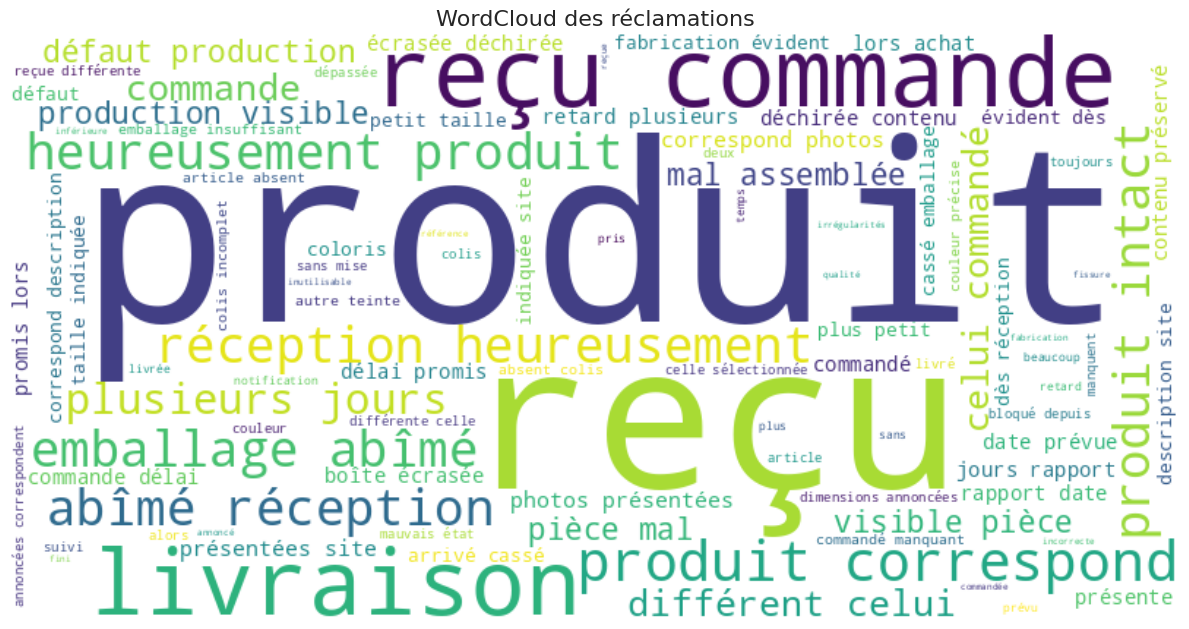

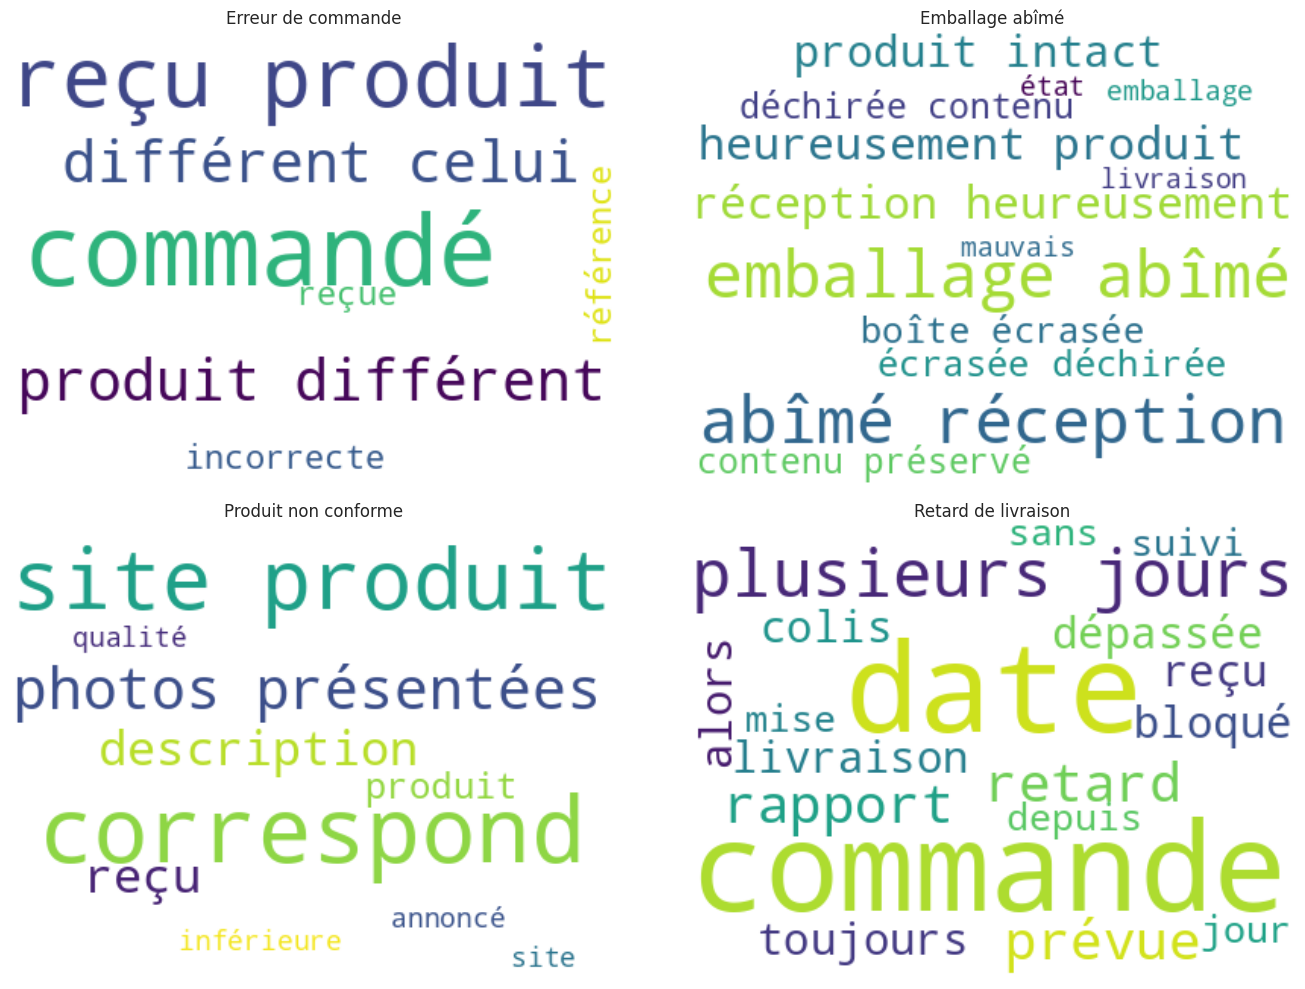

In [9]:
# ============================================
# CELLULE 5 - MOTS LES PLUS FRÉQUENTS
# ============================================

print("="*60)
print("ANALYSE DES MOTS FRÉQUENTS")
print("="*60)

if 'Description_clean' in df_reclamations.columns:
    # Récupérer tous les mots
    all_words = ' '.join(df_reclamations['Description_clean']).split()
    word_counts = Counter(all_words)

    print("Top 20 mots les plus fréquents :")
    for word, count in word_counts.most_common(20):
        print(f"   {word} : {count}")

    # WordCloud
    from wordcloud import WordCloud
    plt.figure(figsize=(12, 8))
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          max_words=100, colormap='viridis').generate(' '.join(all_words))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('WordCloud des réclamations', fontsize=16)
    plt.tight_layout()
    plt.show()

    # WordCloud par type de réclamation
    if 'Type_Reclamation' in df_reclamations.columns:
        types = df_reclamations['Type_Reclamation'].unique()
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        for i, type_name in enumerate(types[:4]):
            row, col = i // 2, i % 2
            type_words = ' '.join(df_reclamations[df_reclamations['Type_Reclamation'] == type_name]['Description_clean'])
            if len(type_words) > 10:
                wc = WordCloud(width=400, height=300, background_color='white', max_words=50).generate(type_words)
                axes[row, col].imshow(wc, interpolation='bilinear')
                axes[row, col].axis('off')
                axes[row, col].set_title(f'{type_name}', fontsize=12)

        plt.tight_layout()
        plt.show()

SENTIMENT ANALYSIS AVEC TEXTBLOB
✅ Sentiment analysis terminé

📊 Distribution des sentiments :
   Neutre : 93 (93.0%)
   Négatif : 7 (7.0%)

📊 Statistiques de polarité :
   Moyenne : -0.0630
   Min : -0.9000
   Max : 0.0000


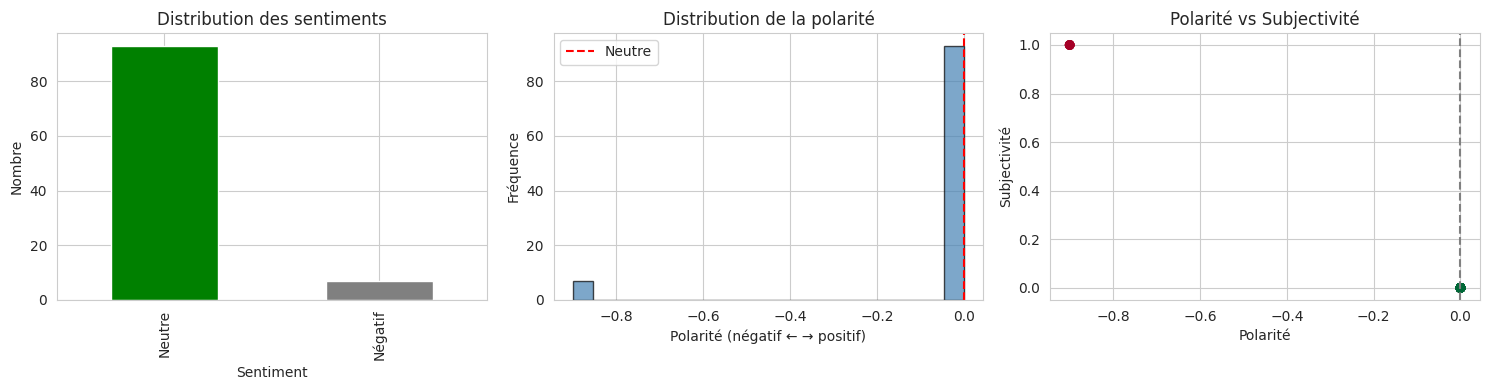

In [10]:
# ============================================
# CELLULE 6 - SENTIMENT ANALYSIS (TEXTBLOB)
# ============================================

print("="*60)
print("SENTIMENT ANALYSIS AVEC TEXTBLOB")
print("="*60)

from textblob import TextBlob

# Fonction pour obtenir le sentiment
def get_sentiment(text):
    """Retourne le sentiment d'un texte (polarity et subjectivity)"""
    if pd.isna(text) or text == "":
        return 0, 0
    try:
        blob = TextBlob(text)
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    except:
        return 0, 0

def get_sentiment_label(polarity):
    """Convertit la polarité en label"""
    if polarity > 0.1:
        return 'Positif'
    elif polarity < -0.1:
        return 'Négatif'
    else:
        return 'Neutre'

if 'Description_clean' in df_reclamations.columns:
    # Appliquer l'analyse de sentiment
    df_reclamations['polarity'], df_reclamations['subjectivity'] = zip(*df_reclamations['Description_clean'].apply(get_sentiment))
    df_reclamations['sentiment'] = df_reclamations['polarity'].apply(get_sentiment_label)

    print("✅ Sentiment analysis terminé")

    # Distribution des sentiments
    print("\n📊 Distribution des sentiments :")
    sentiment_counts = df_reclamations['sentiment'].value_counts()
    for sent, count in sentiment_counts.items():
        print(f"   {sent} : {count} ({count/len(df_reclamations)*100:.1f}%)")

    # Statistiques
    print(f"\n📊 Statistiques de polarité :")
    print(f"   Moyenne : {df_reclamations['polarity'].mean():.4f}")
    print(f"   Min : {df_reclamations['polarity'].min():.4f}")
    print(f"   Max : {df_reclamations['polarity'].max():.4f}")

    # Visualisation
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Distribution des sentiments
    sentiment_counts.plot(kind='bar', ax=axes[0], color=['green', 'gray', 'red'])
    axes[0].set_title('Distribution des sentiments')
    axes[0].set_xlabel('Sentiment')
    axes[0].set_ylabel('Nombre')

    # Distribution de la polarité
    axes[1].hist(df_reclamations['polarity'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='red', linestyle='--', label='Neutre')
    axes[1].set_xlabel('Polarité (négatif ← → positif)')
    axes[1].set_ylabel('Fréquence')
    axes[1].set_title('Distribution de la polarité')
    axes[1].legend()

    # Subjectivité vs Polarité
    axes[2].scatter(df_reclamations['polarity'], df_reclamations['subjectivity'],
                    c=df_reclamations['polarity'], cmap='RdYlGn', alpha=0.7)
    axes[2].set_xlabel('Polarité')
    axes[2].set_ylabel('Subjectivité')
    axes[2].set_title('Polarité vs Subjectivité')
    axes[2].axvline(x=0, color='gray', linestyle='--')

    plt.tight_layout()
    plt.show()

SENTIMENT PAR TYPE DE RÉCLAMATION
Polarité moyenne par type de réclamation :
   Couleur différente : 0.0000 (11.0 récl.) → ⚪ Neutre
   Défaut de fabrication : 0.0000 (11.0 récl.) → ⚪ Neutre
   Emballage abîmé : 0.0000 (16.0 récl.) → ⚪ Neutre
   Erreur de commande : 0.0000 (7.0 récl.) → ⚪ Neutre
   Produit endommagé : 0.0000 (5.0 récl.) → ⚪ Neutre
   Produit manquant : 0.0000 (11.0 récl.) → ⚪ Neutre
   Taille incorrecte : 0.0000 (8.0 récl.) → ⚪ Neutre
   Produit non conforme : 0.0000 (11.0 récl.) → ⚪ Neutre
   Livraison tardive : -0.2000 (9.0 récl.) → 🔴 Négatif
   Retard de livraison : -0.4091 (11.0 récl.) → 🔴 Négatif


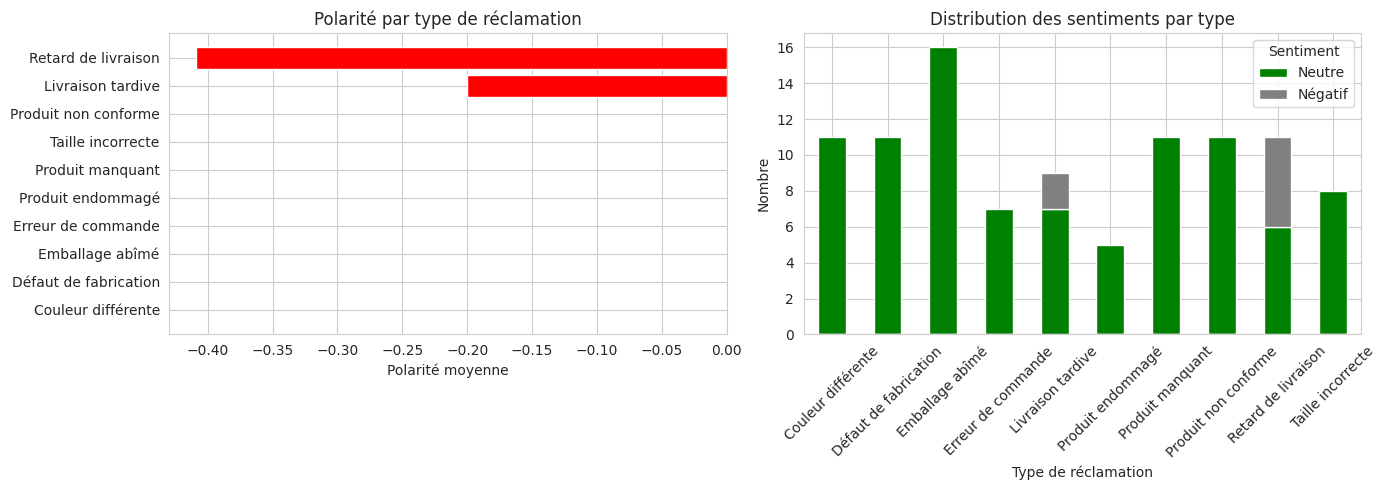

In [11]:
# ============================================
# CELLULE 7 - SENTIMENT PAR TYPE DE RÉCLAMATION
# ============================================

print("="*60)
print("SENTIMENT PAR TYPE DE RÉCLAMATION")
print("="*60)

if 'Type_Reclamation' in df_reclamations.columns and 'polarity' in df_reclamations.columns:
    # Polarité moyenne par type
    type_sentiment = df_reclamations.groupby('Type_Reclamation')['polarity'].agg(['mean', 'count'])
    type_sentiment = type_sentiment.sort_values('mean', ascending=False)

    print("Polarité moyenne par type de réclamation :")
    for type_name, row in type_sentiment.iterrows():
        sentiment_text = "🟢 Positif" if row['mean'] > 0 else "🔴 Négatif" if row['mean'] < 0 else "⚪ Neutre"
        print(f"   {type_name} : {row['mean']:.4f} ({row['count']} récl.) → {sentiment_text}")

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Polarité moyenne
    colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in type_sentiment['mean']]
    axes[0].barh(type_sentiment.index, type_sentiment['mean'], color=colors)
    axes[0].set_xlabel('Polarité moyenne')
    axes[0].set_title('Polarité par type de réclamation')
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

    # Heatmap sentiment vs type
    sentiment_by_type = pd.crosstab(df_reclamations['Type_Reclamation'], df_reclamations['sentiment'])
    sentiment_by_type.plot(kind='bar', stacked=True, ax=axes[1], color=['green', 'gray', 'red'])
    axes[1].set_title('Distribution des sentiments par type')
    axes[1].set_xlabel('Type de réclamation')
    axes[1].set_ylabel('Nombre')
    axes[1].legend(title='Sentiment')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

MOTS-CLÉS PAR SENTIMENT

📌 Sentiment Positif :
   Aucune réclamation avec ce sentiment

📌 Sentiment Neutre :
   produit : 51
   reçu : 28
   commande : 16
   commandé : 15
   emballage : 15
   correspond : 15
   site : 14
   réception : 12
   livraison : 11
   colis : 11

📌 Sentiment Négatif :
   commande : 7
   retard : 7
   jours : 7
   plusieurs : 5
   rapport : 5
   date : 5
   prévue : 5
   livrée : 2
   sans : 2
   notification : 2


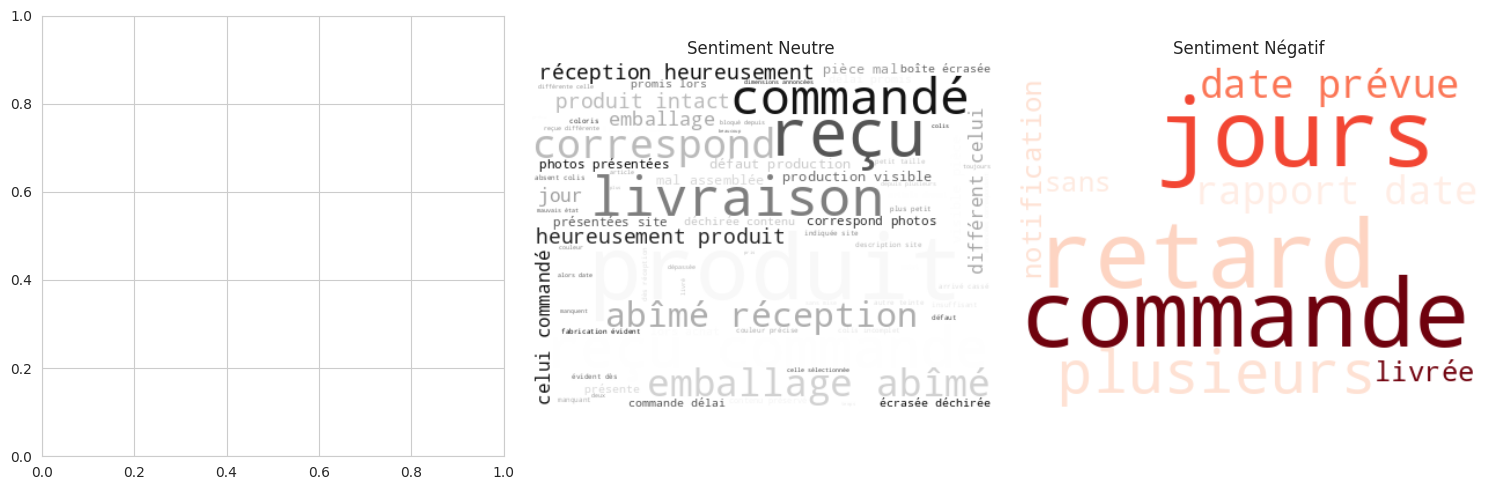

In [12]:
# ============================================
# CELLULE 8 - MOTS-CLÉS PAR SENTIMENT
# ============================================

print("="*60)
print("MOTS-CLÉS PAR SENTIMENT")
print("="*60)

if 'Description_clean' in df_reclamations.columns and 'sentiment' in df_reclamations.columns:
    # Fonction pour extraire les mots les plus fréquents par sentiment
    def get_top_words_by_sentiment(df, sentiment_label, n=10):
        texts = df[df['sentiment'] == sentiment_label]['Description_clean']
        if len(texts) == 0:
            return []
        all_words = ' '.join(texts).split()
        word_counts = Counter(all_words)
        return word_counts.most_common(n)

    for sentiment in ['Positif', 'Neutre', 'Négatif']:
        print(f"\n📌 Sentiment {sentiment} :")
        top_words = get_top_words_by_sentiment(df_reclamations, sentiment, 10)
        if top_words:
            for word, count in top_words:
                print(f"   {word} : {count}")
        else:
            print(f"   Aucune réclamation avec ce sentiment")

    # WordCloud par sentiment
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, sentiment in enumerate(['Positif', 'Neutre', 'Négatif']):
        texts = ' '.join(df_reclamations[df_reclamations['sentiment'] == sentiment]['Description_clean'])
        if len(texts) > 10:
            color = 'Greens' if sentiment == 'Positif' else 'Greys' if sentiment == 'Neutre' else 'Reds'
            wc = WordCloud(width=400, height=300, background_color='white', colormap=color).generate(texts)
            axes[i].imshow(wc, interpolation='bilinear')
            axes[i].axis('off')
            axes[i].set_title(f'Sentiment {sentiment}', fontsize=12)

    plt.tight_layout()
    plt.show()

CLASSIFICATION AUTOMATIQUE DES SENTIMENTS
Accuracy : 0.9667

Classification Report :
              precision    recall  f1-score   support

      Neutre       0.97      1.00      0.98        28
     Négatif       1.00      0.50      0.67         2

    accuracy                           0.97        30
   macro avg       0.98      0.75      0.82        30
weighted avg       0.97      0.97      0.96        30



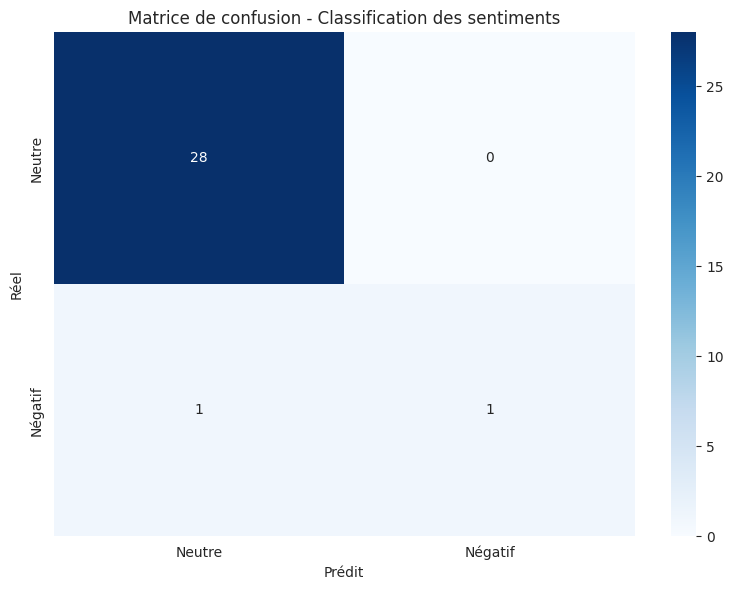


📝 Interprétation :
   - Le modèle peut prédire automatiquement le sentiment d'une réclamation
   - Utile pour trier automatiquement les nouvelles réclamations


In [13]:
# ============================================
# CELLULE 9 - CLASSIFICATION AUTOMATIQUE
# ============================================

print("="*60)
print("CLASSIFICATION AUTOMATIQUE DES SENTIMENTS")
print("="*60)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

if 'Description_clean' in df_reclamations.columns and 'sentiment' in df_reclamations.columns:
    # Supprimer les lignes avec sentiment vide
    df_clean = df_reclamations[df_reclamations['sentiment'].notna()]

    # Préparer les données
    X = df_clean['Description_clean']
    y = df_clean['sentiment']

    # Encoder les labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

    # Vectorisation TF-IDF
    vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Modèle Naive Bayes
    model = MultinomialNB()
    model.fit(X_train_tfidf, y_train)

    # Prédictions
    y_pred = model.predict(X_test_tfidf)

    # Métriques
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report :")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Matrice de confusion
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title('Matrice de confusion - Classification des sentiments')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.tight_layout()
    plt.show()

    print("\n📝 Interprétation :")
    print("   - Le modèle peut prédire automatiquement le sentiment d'une réclamation")
    print("   - Utile pour trier automatiquement les nouvelles réclamations")

In [14]:
# ============================================
# CELLULE 10 - EXEMPLES PAR SENTIMENT
# ============================================

print("="*60)
print("EXEMPLES DE RÉCLAMATIONS PAR SENTIMENT")
print("="*60)

if 'sentiment' in df_reclamations.columns and 'Description' in df_reclamations.columns:
    # Exemples positifs
    print("\n🔵 RÉCLAMATIONS POSITIVES :")
    positive_examples = df_reclamations[df_reclamations['sentiment'] == 'Positif']['Description'].head(3)
    for i, example in enumerate(positive_examples):
        print(f"   {i+1}. {str(example)[:150]}...")

    # Exemples négatifs
    print("\n🔴 RÉCLAMATIONS NÉGATIVES :")
    negative_examples = df_reclamations[df_reclamations['sentiment'] == 'Négatif']['Description'].head(3)
    for i, example in enumerate(negative_examples):
        print(f"   {i+1}. {str(example)[:150]}...")

    # Exemples neutres
    print("\n⚪ RÉCLAMATIONS NEUTRES :")
    neutral_examples = df_reclamations[df_reclamations['sentiment'] == 'Neutre']['Description'].head(3)
    for i, example in enumerate(neutral_examples):
        print(f"   {i+1}. {str(example)[:150]}...")

EXEMPLES DE RÉCLAMATIONS PAR SENTIMENT

🔵 RÉCLAMATIONS POSITIVES :

🔴 RÉCLAMATIONS NÉGATIVES :
   1. La commande est en retard de plusieurs jours par rapport à la date prévue....
   2. La commande est en retard de plusieurs jours par rapport à la date prévue....
   3. La commande est en retard de plusieurs jours par rapport à la date prévue....

⚪ RÉCLAMATIONS NEUTRES :
   1. J'ai reçu un produit différent de celui que j'avais commandé....
   2. L'emballage est très abîmé à la réception, heureusement le produit est intact....
   3. Le produit reçu ne correspond pas à la description sur le site....


In [15]:
# ============================================
# CELLULE 11 - INTERPRÉTATION MÉTIER
# ============================================

print("="*60)
print("INTERPRÉTATION MÉTIER - NLP")
print("="*60)

if 'sentiment' in df_reclamations.columns:
    sentiment_counts = df_reclamations['sentiment'].value_counts()
    most_common_sentiment = sentiment_counts.idxmax() if len(sentiment_counts) > 0 else "inconnu"

    if 'Type_Reclamation' in df_reclamations.columns:
        type_sentiment = df_reclamations.groupby('Type_Reclamation')['polarity'].mean()
        worst_type = type_sentiment.idxmin() if len(type_sentiment) > 0 else "inconnu"
    else:
        worst_type = "non disponible"

    print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION NLP - SENTIMENT ANALYSIS                       │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 STATISTIQUES CLÉS :                                                     │
│  ---------------------------------                                           │
│  • Nombre total de réclamations : {}                                        │
│                                                                             │
│  📈 INSIGHTS MÉTIER :                                                       │
│  ---------------------------------                                           │
│  • Les réclamations sont majoritairement {}                                 │
│  • Le sentiment le plus négatif est associé aux réclamations de type {}     │
│                                                                             │
│  💡 RECOMMANDATIONS :                                                       │
│  ---------------------------------                                           │
│  • Prioriser le traitement des réclamations négatives                       │
│  • Automatiser la classification avec le modèle Naive Bayes                 │
│  • Analyser les mots-clés pour identifier les causes récurrentes            │
│  • Former l'équipe SAV sur les problèmes les plus fréquents                 │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""".format(
    len(df_reclamations),
    most_common_sentiment,
    worst_type
    ))
else:
    print("⚠️ Données de sentiment non disponibles")

print("\n✅ NLP - SENTIMENT ANALYSIS TERMINÉ !")

INTERPRÉTATION MÉTIER - NLP

┌─────────────────────────────────────────────────────────────────────────────┐
│                    CONCLUSION NLP - SENTIMENT ANALYSIS                       │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 STATISTIQUES CLÉS :                                                     │
│  ---------------------------------                                           │
│  • Nombre total de réclamations : 100                                        │
│                                                                             │
│  📈 INSIGHTS MÉTIER :                                                       │
│  ---------------------------------                                           │
│  • Les réclamations sont majoritairement Neutre                                 │
│  • Le sentiment le plus négatif est associé aux réclamations de type Retard de livr